# IPL Data Analysis & Dashboard (2008-2023)
*by* **Deependra Sirana**

**Description:** A complete exploratory data analysis of IPL cricket match data from 2008–2023. This project finds patterns in team performance, top batters, bowling economy, win rates by venue, and toss decisions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading & First Look
Loading the `matches.csv` and `deliveries.csv` files and inspect their structure.

### Meaning of each column used

**Matches Dataset (`matches.csv`)**
- `id`: Unique match identifier
- `season`: IPL season year
- `city`: City where the match was played
- `date`: Date of the match
- `match_type`: Type of match (League, Final, etc.)
- `player_of_match`: Player awarded Man of the Match
- `venue`: Stadium name
- `team1`, `team2`: Participating team names
- `toss_winner`: Team that won the toss
- `toss_decision`: Decision after winning the toss (bat/field)
- `winner`: Match winner
- `result`: Result type (runs, wickets, tie, no result)
- `result_margin`: Margin of victory
- `target_runs`, `target_overs`: Target set (if applicable)
- `super_over`: Whether there was a super over (Y/N)
- `method`: How the result was decided when the match didn't complete normally
- `umpire1`, `umpire2`: On-field umpires

**Deliveries Dataset (`deliveries.csv`)**
- `match_id`: Identifier linking to matches dataset
- `inning`: Inning number (1 or 2)
- `batting_team`, `bowling_team`: Teams batting and bowling
- `over`, `ball`: Over and ball number
- `batter`, `bowler`, `non_striker`: Players involved
- `batsman_runs`: Runs scored off the bat
- `extra_runs`: Extras conceded (wides, noballs, etc.)
- `total_runs`: Total runs from the delivery
- `extras_type`: Type of extra
- `is_wicket`: Indicator if a wicket fell (0 or 1)
- `player_dismissed`, `dismissal_kind`, `fielder`: Dismissal details

In [2]:
# Loading datasets
matches = pd.read_csv("Sources/matches.csv")
deliveries = pd.read_csv("Sources/deliveries.csv")

print("--- Matches Dataset ---")
display(matches.head())
print("\nMatches Info:")
display(matches.info())
print("\nMatches Describe:")
display(matches.describe())
print("\nMatches Null Values:")
display(matches.isnull().sum())

print("\n\n", "-"*100, "\n")

print("\n--- Deliveries Dataset ---")
display(deliveries.head())
print("\nDeliveries Info:")
display(deliveries.info())
print("\nDeliveries Null Values:")
display(deliveries.isnull().sum())

--- Matches Dataset ---


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan



Matches Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17 

None


Matches Describe:


...

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN



Deliveries Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           93

None


Deliveries Null Values:


match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Data Cleaning
- Replaced outdated team names with their current active names for consistency.
- Converted the `date` column in `matches` to `datetime`.
- Filled missing `city` values using the `venue` information (e.g., Dubai International Cricket Stadium -> Dubai).
- Left `umpire` missing values as they don't impact our core analysis.

In [3]:
# 1. Standardising Team Names
team_name_changes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

matches.replace(team_name_changes, inplace=True)
deliveries.replace(team_name_changes, inplace=True)

# 2. Converting date to datetime
matches['date'] = pd.to_datetime(matches['date'])

# 3. Handling missing values in 'city' based on 'venue'
venue_city_names = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah',
    'Sheikh Zayed Stadium': 'Abu Dhabi'
}
matches['city'] = matches['city'].fillna(matches['venue'].map(venue_city_names))

# 4. Handling stadium names
stadium_names = {
	'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium, Bengaluru',
    'Brabourne Stadium': 'Brabourne Stadium, Mumbai',
	'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium, Hyderabad',
	'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association IS Bindra Stadium, Chandigarh',
	'Dubai International Cricket Stadium': 'Dubai International Cricket Stadium, Dubai',
    'Sharjah Cricket Stadium': 'Sharjah Cricket Stadium, Sharjah',
    'Sheikh Zayed Stadium': 'Sheikh Zayed Stadium, Abu Dhabi'
}
matches.replace(stadium_names, inplace=True)

print("Null values in 'city' column:", matches['city'].isnull().sum())

Null values in 'city' column: 0


## Analysis & Visualizations

### 1. Total matches won by each team across all seasons

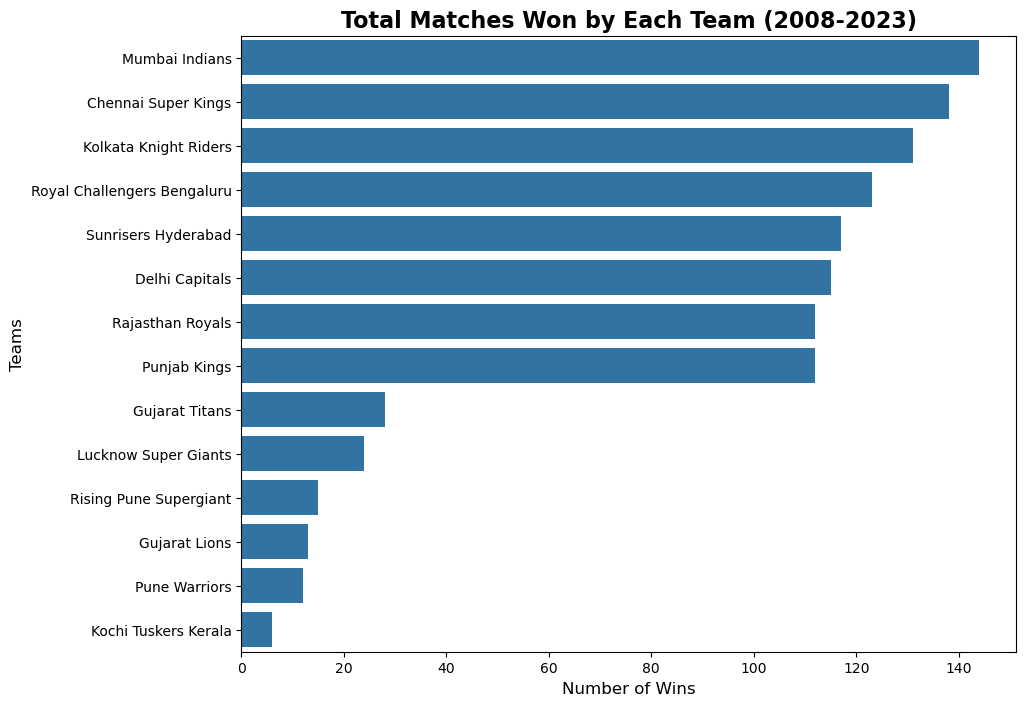

In [4]:
wins = matches['winner'].value_counts()
plt.figure(figsize=(10, 8))
sns.barplot(y=wins.index, x=wins.values)
plt.title('Total Matches Won by Each Team (2008-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Teams', fontsize=12)
plt.show()

### 2. Top 10 run scorers across all seasons

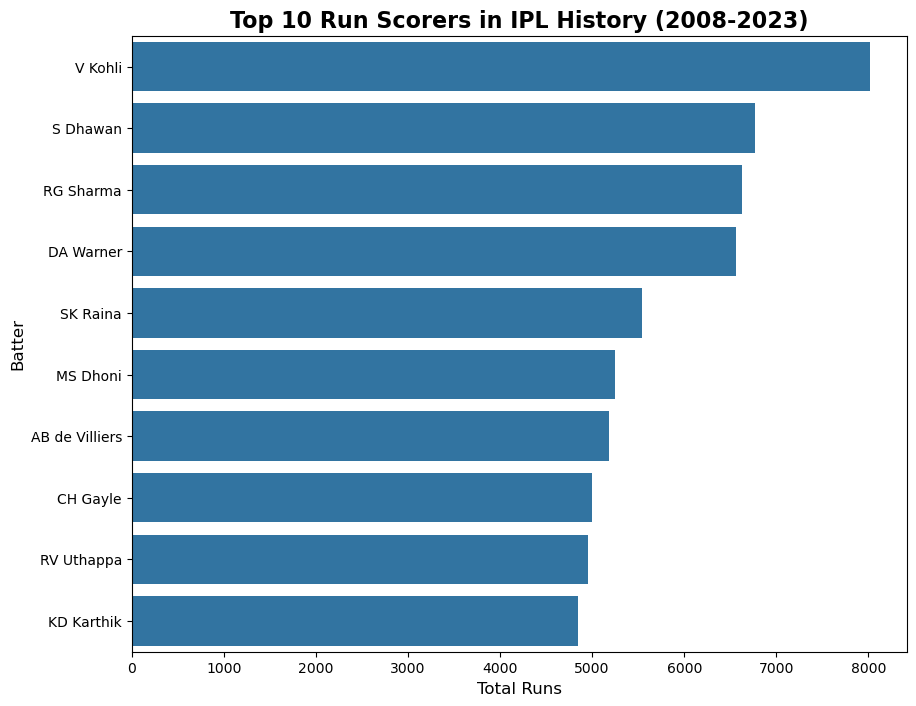

In [5]:
plt.figure(figsize=(10, 8))
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_batsmen.index, x=top_batsmen.values)
plt.title('Top 10 Run Scorers in IPL History (2008-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Batter', fontsize=12)
plt.show()

### 3. Top 10 wicket-takers across all seasons

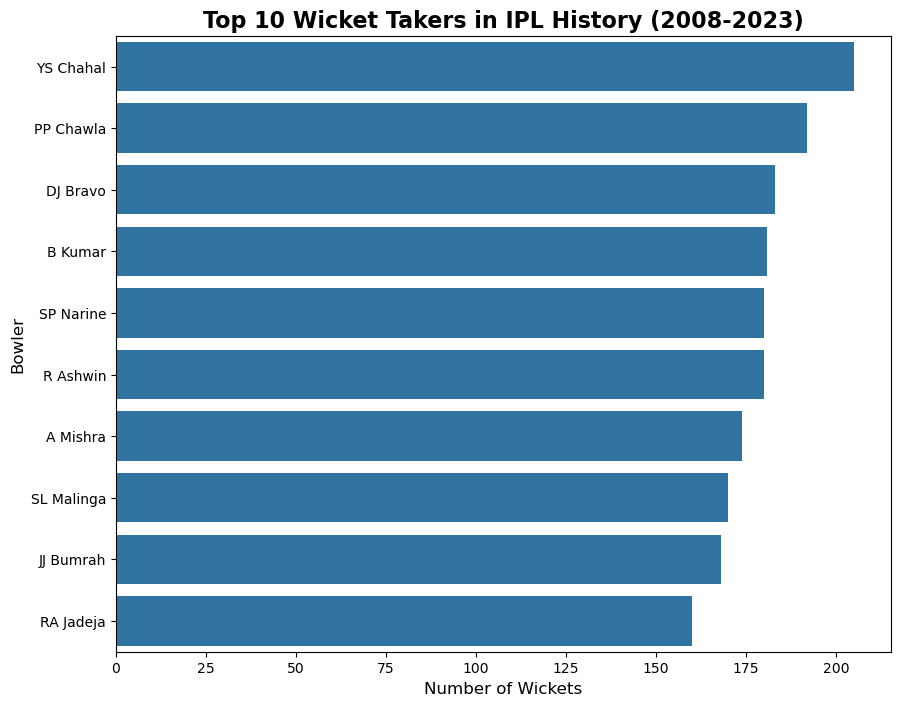

In [6]:
plt.figure(figsize=(10, 8))
bowler_wickets = deliveries[deliveries['dismissal_kind'].isin(['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled'])]
top_bowlers = bowler_wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_bowlers.index, x=top_bowlers.values)
plt.title('Top 10 Wicket Takers in IPL History (2008-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.show()

### 4. Win Percentage: Batting First vs Chasing

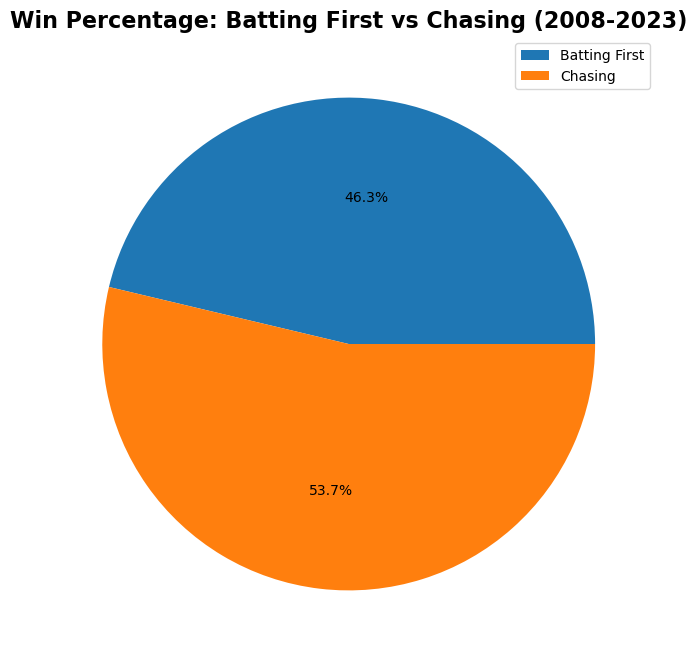

In [7]:
plt.figure(figsize=(10, 8))
# Result = 'runs' means batting first team won, 'wickets' means chasing team won
batting_first = matches[matches['result'] == 'runs'].shape[0]
chasing = matches[matches['result'] == 'wickets'].shape[0]
labels = ['Batting First', 'Chasing']
sizes = [batting_first, chasing]
plt.pie(sizes, autopct='%1.1f%%')
plt.legend(labels=labels)
plt.title('Win Percentage: Batting First vs Chasing (2008-2023)', fontsize=16, fontweight='bold')
plt.show()

### 5. Most successful venues by average runs scored

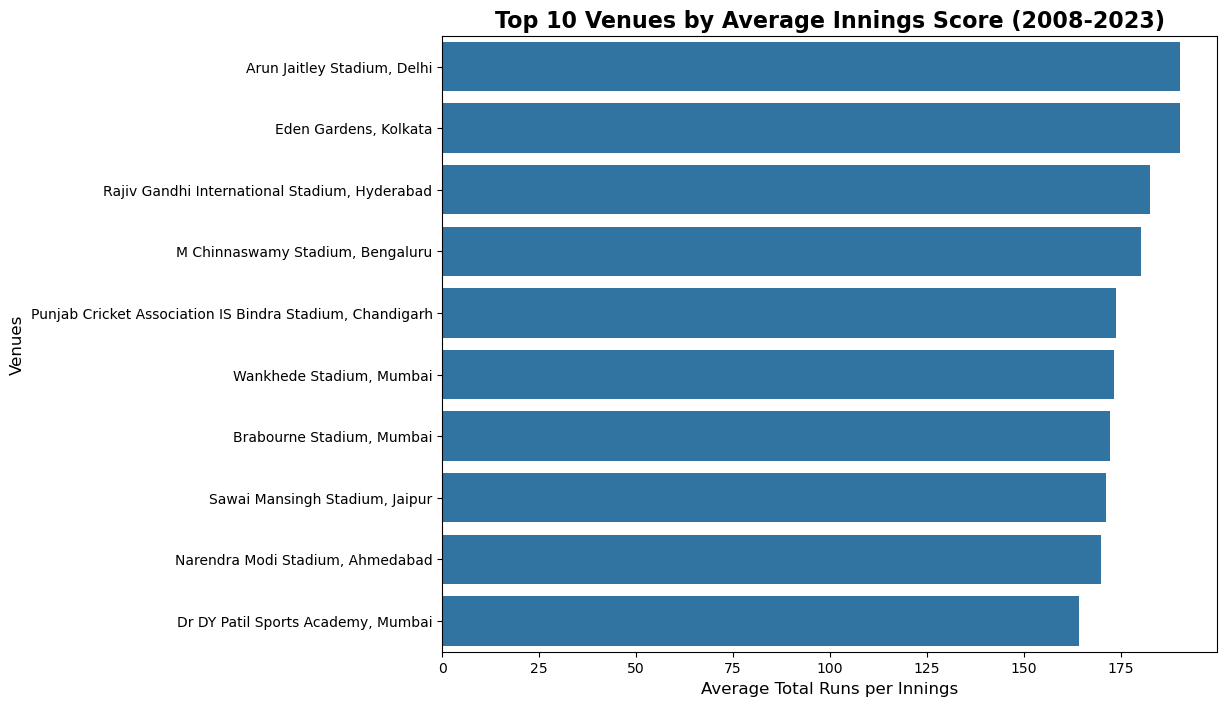

In [8]:
# Total runs per match
match_runs = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
# Merge with venue
match_venues = match_runs.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
# Average runs per venue
venue_avg = match_venues.groupby('venue').agg({'total_runs': 'mean', 'match_id': 'nunique'})
venue_avg = venue_avg[venue_avg['match_id'] >= 10].sort_values(by='total_runs', ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(y=venue_avg.index, x=venue_avg['total_runs'])
plt.title('Top 10 Venues by Average Innings Score (2008-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Average Total Runs per Innings', fontsize=12)
plt.ylabel('Venues', fontsize=12)
plt.show()

### 6. Toss Decision and Match Outcome

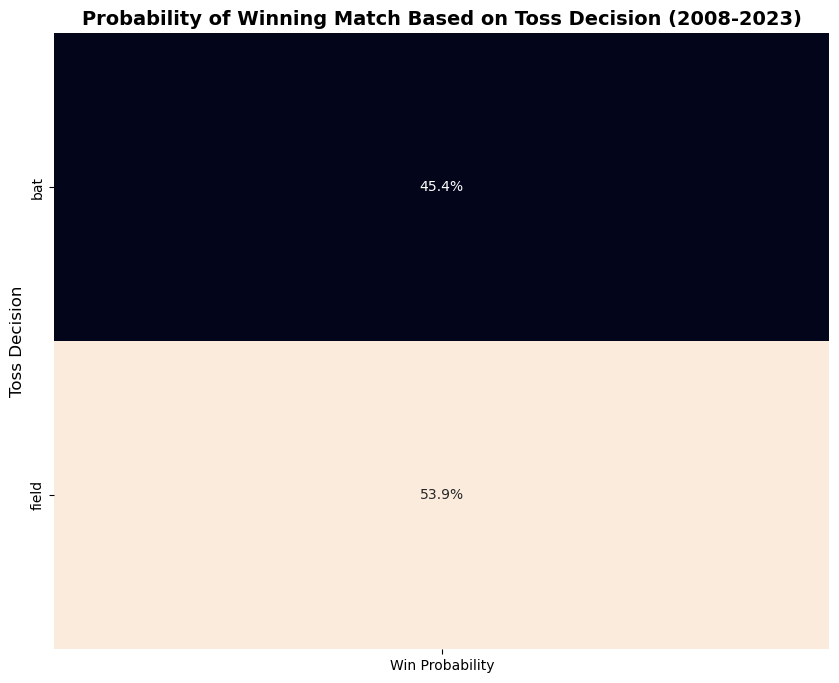

In [9]:
# Checking if toss_winner is the match_winner
matches_valid = matches.dropna(subset=['winner', 'toss_decision', 'toss_winner'])
matches_valid = matches_valid.copy()
matches_valid['toss_winner_is_winner'] = (matches_valid['toss_winner'] == matches_valid['winner']).astype(int)

toss_pivot = pd.pivot_table(matches_valid, values='toss_winner_is_winner', index='toss_decision', aggfunc=['mean', 'count'])
toss_pivot.columns = ['Win Probability', 'Match Count']

plt.figure(figsize=(10, 8))
sns.heatmap(toss_pivot[['Win Probability']], annot=True, fmt='.1%', cbar=False)
plt.title('Probability of Winning Match Based on Toss Decision (2008-2023)', fontsize=14, fontweight='bold')
plt.ylabel('Toss Decision', fontsize=12)
plt.show()

## Insights & Conclusion

- **Mumbai Indians** and **Chennai Super Kings** are the most dominant teams in IPL history, leading the chart for total match wins.
- **Virat Kohli** and **Shikhar Dhawan** top the run-scoring charts, showing incredible consistency across seasons.
- Spinners and experienced pacers like **Yuzvendra Chahal**, **Piyush Chawla**, and **Lasith Malinga** dominate the highest wicket-takers list.
- **Chasing is generally more advantageous**: Teams batting second (chasing) have won ~53% of matches, while teams batting first won ~47%.
- Venues like **Brabourne Stadium** and **M Chinnaswamy Stadium** are highly favorable for batting, boasting the highest average innings scores.
- Teams winning the toss and choosing to **field first** have a slightly higher match-win probability compared to those choosing to bat first.